# Classical Forecasting Models

> **AUTHORITATIVE VALIDATED CLASSICAL RESULTS**  
> Every final forecast in this notebook uses a past-only validated protocol. Naive, the 7-Day Moving Average, ARIMA, Simple Exponential Smoothing, and Holt-Winters are rolling one-step forecasts. Prophet is retained only as an explicitly different 30-day periodic-refit comparator.

Early static multi-step classical forecasts were used during development but were excluded after protocol audit because they were not comparable with the rolling one-step evaluation. Final classical results therefore use only validated past-only protocols.


## 1. Import Libraries

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_bitcoin_data
from src.preprocessing import prepare_daily_bitcoin_data
from src.metrics import forecast_metric_row as evaluate_forecast

def load_frozen_forecast(filename, value_column, display_name, expected_index):
    frame = pd.read_csv(PROJECT_ROOT / "results" / filename, parse_dates=["Timestamp"]).set_index("Timestamp")
    frame.index = pd.to_datetime(frame.index, utc=True)
    forecast = frame[value_column].reindex(expected_index).rename(display_name)
    assert forecast.index.equals(expected_index)
    assert forecast.notna().all() and np.isfinite(forecast.to_numpy(dtype=float)).all()
    return forecast


## 2. Load Dataset

In [2]:
data_path = PROJECT_ROOT / "data" / "bitcoin" / "btcusd_1-min_data.csv"

df_raw = load_bitcoin_data(data_path)
df_daily = prepare_daily_bitcoin_data(df_raw)
df_daily.head()

,Open,High,Low,Close,Volume
Timestamp,,,,,
2012-01-01 00:00:00+00:00,4.58,5.00,4.58,5.00,21.602000
2012-01-02 00:00:00+00:00,5.00,5.00,5.00,5.00,19.048000
2012-01-03 00:00:00+00:00,5.00,5.32,5.00,5.29,88.037281
2012-01-04 00:00:00+00:00,5.29,5.57,4.93,5.57,107.233260
2012-01-05 00:00:00+00:00,5.57,6.65,5.57,6.65,94.801829


## 3. Train-Test Split

In [3]:
target = df_daily["Close"].dropna().asfreq("D")
split_idx = int(len(target) * 0.8)

train = target.iloc[:split_idx]
test = target.iloc[split_idx:]
y_test = test.copy()

train.shape, test.shape

((4241,), (1061,))

## 4. Naive Forecast

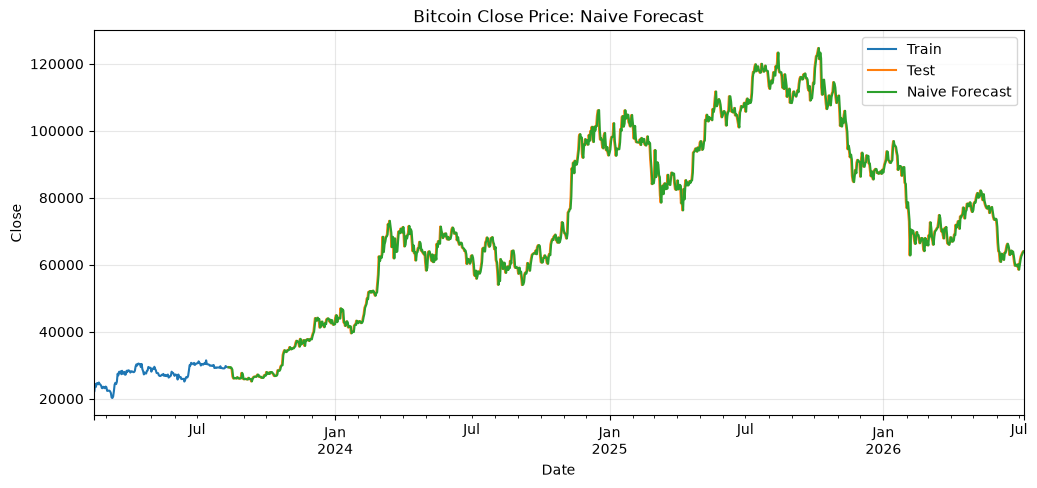

In [4]:
naive_forecast = target.shift(1).reindex(test.index).rename("Naive")

fig, ax = plt.subplots(figsize=(12, 5))
train.tail(180).plot(ax=ax, label="Train")
test.plot(ax=ax, label="Test")
naive_forecast.plot(ax=ax, label="Naive Forecast")
ax.set_title("Bitcoin Close Price: Naive Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Close")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 5. Moving Average Forecast

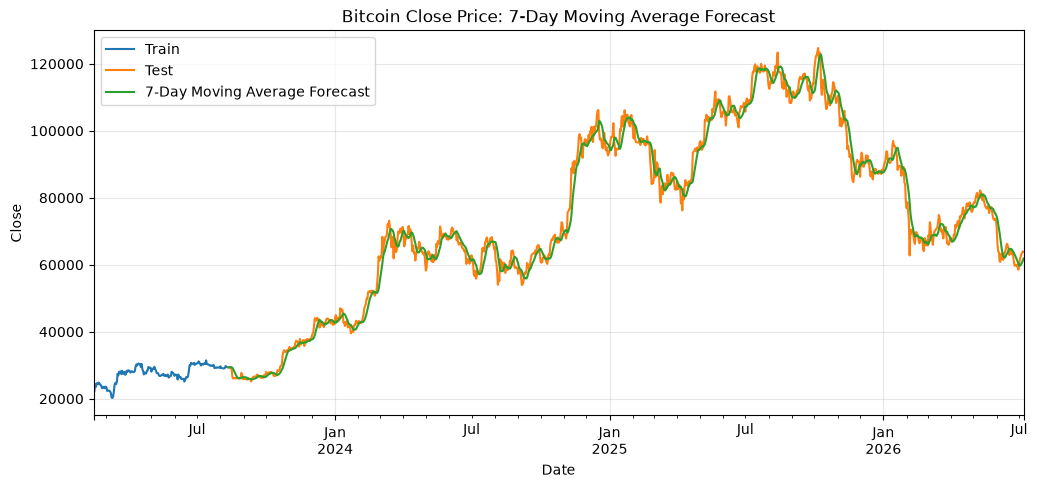

In [5]:
moving_average_forecast = (
    target.shift(1)
    .rolling(window=7)
    .mean()
    .reindex(test.index)
    .rename("7-Day Moving Average")
)

fig, ax = plt.subplots(figsize=(12, 5))
train.tail(180).plot(ax=ax, label="Train")
test.plot(ax=ax, label="Test")
moving_average_forecast.plot(ax=ax, label="7-Day Moving Average Forecast")
ax.set_title("Bitcoin Close Price: 7-Day Moving Average Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Close")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 6. Exponential Smoothing — Rolling One-Step Protocol

Validated rolling artifacts exist for both Simple Exponential Smoothing and additive-trend, non-seasonal Holt-Winters. Each frozen forecast was produced from the latest 128 observations strictly before its target date. This notebook loads those artifacts without refitting either model.


In [6]:
simple_exp_rolling_forecast = load_frozen_forecast(
    "simple_exp_smoothing_forecast.csv", "Simple_Exp_Smoothing",
    "Simple Exponential Smoothing Rolling One-Step", test.index,
)
pd.DataFrame([evaluate_forecast(test, simple_exp_rolling_forecast)], index=[simple_exp_rolling_forecast.name])


,MAE,RMSE,MAPE,sMAPE
Simple Exponential Smoothing Rolling One-Step,1290.358684,1855.731424,1.742685,1.743871


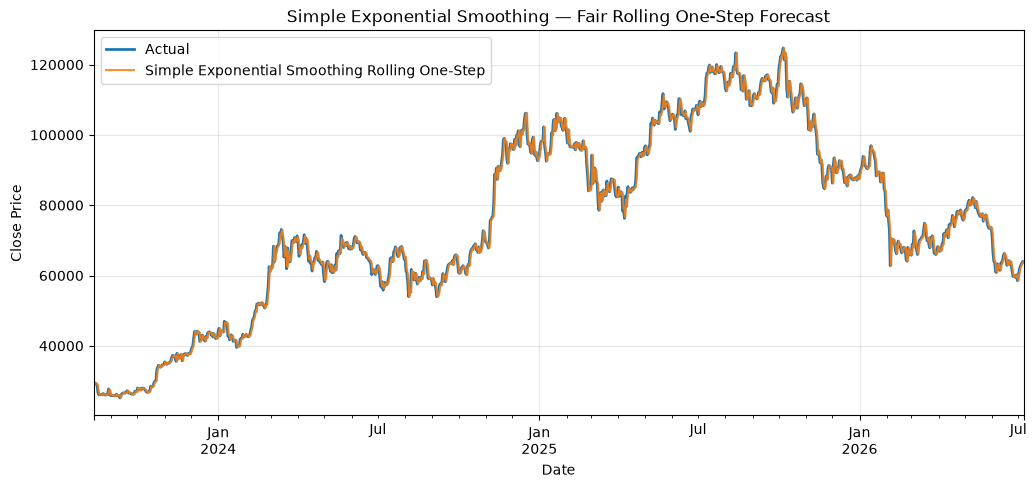

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
test.plot(ax=ax, label="Actual", linewidth=2)
simple_exp_rolling_forecast.plot(ax=ax, label="Simple Exponential Smoothing Rolling One-Step", alpha=0.85)
ax.set_title("Simple Exponential Smoothing — Fair Rolling One-Step Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Close Price")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


### 6.1 Holt-Winters — Rolling One-Step Protocol

The validated Holt-Winters artifact uses an additive trend without a seasonal component. A weekly SARIMA specification was not retained because the seasonality audit found lag-7 ACF `-0.023409` within the approximate 95% bound `±0.026920`, with weak weekly STL strength `0.069923`.


In [8]:
holt_winters_rolling_forecast = load_frozen_forecast(
    "holt_winters_forecast.csv", "Holt_Winters",
    "Holt-Winters Rolling One-Step", test.index,
)
pd.DataFrame([evaluate_forecast(test, holt_winters_rolling_forecast)], index=[holt_winters_rolling_forecast.name])


,MAE,RMSE,MAPE,sMAPE
Holt-Winters Rolling One-Step,1308.541314,1871.702185,1.76364,1.763424


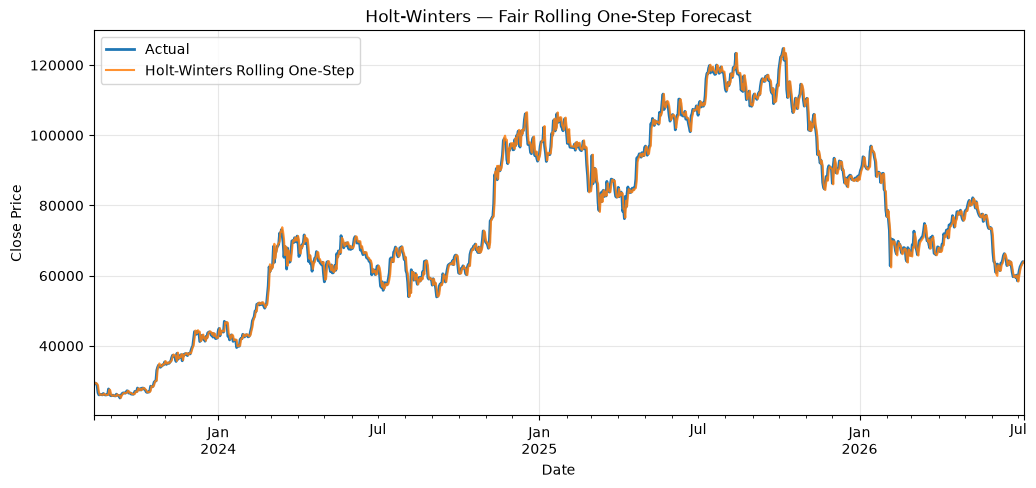

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
test.plot(ax=ax, label="Actual", linewidth=2)
holt_winters_rolling_forecast.plot(ax=ax, label="Holt-Winters Rolling One-Step", alpha=0.85)
ax.set_title("Holt-Winters — Fair Rolling One-Step Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Close Price")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


## 7. ARIMA — Rolling One-Step Protocol

The frozen ARIMA forecast uses the authoritative rolling one-step information structure: forecast target date *t* from observations strictly before *t*, record the forecast, then reveal actual *t* for possible use at *t+1*. It is directly comparable with Naive and the other rolling one-step Bitcoin forecasts. No ARIMA model is refitted here.


In [10]:
arima_rolling_forecast = load_frozen_forecast(
    "arima_rolling_forecast.csv", "ARIMA_Rolling",
    "ARIMA Rolling One-Step", test.index,
)
pd.DataFrame([evaluate_forecast(test, arima_rolling_forecast)], index=[arima_rolling_forecast.name])


,MAE,RMSE,MAPE,sMAPE
ARIMA Rolling One-Step,1299.874638,1866.302859,1.754004,1.754209


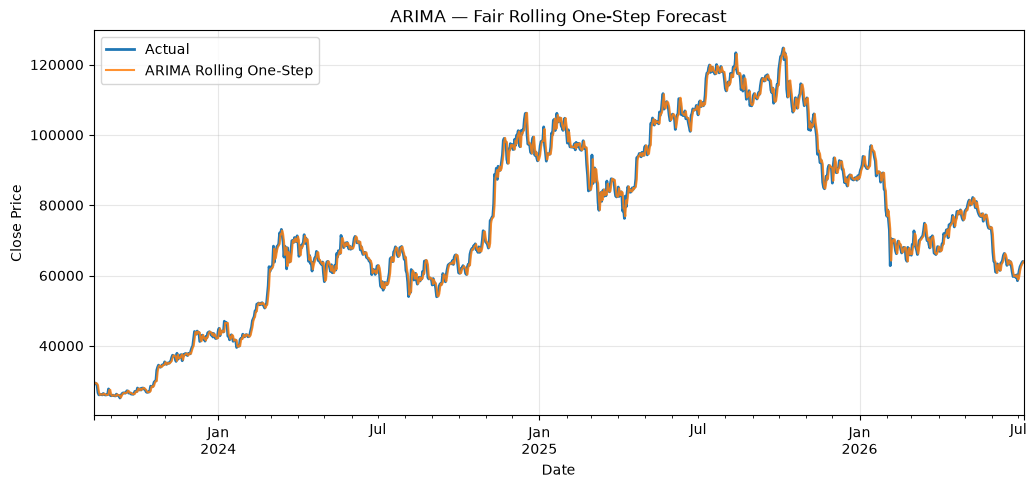

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
test.plot(ax=ax, label="Actual", linewidth=2)
arima_rolling_forecast.plot(ax=ax, label="ARIMA Rolling One-Step", alpha=0.85)
ax.set_title("ARIMA — Fair Rolling One-Step Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Close Price")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


## 8. Final Classical Comparison — Validated Protocols

The first five entries are directly comparable rolling one-step forecasts. Prophet is shown separately as a past-only **30-day periodic-refit** comparator and must not be described as daily rolling refit.


In [12]:
prophet_forecast = load_frozen_forecast(
    "prophet_rolling_forecast.csv", "Prophet_Periodic_Refit",
    "Prophet — 30-Day Periodic Refit", test.index,
)

forecasts = {
    "Naive": naive_forecast,
    "Simple Exponential Smoothing Rolling One-Step": simple_exp_rolling_forecast,
    "ARIMA Rolling One-Step": arima_rolling_forecast,
    "Holt-Winters Rolling One-Step": holt_winters_rolling_forecast,
    "7-Day Moving Average": moving_average_forecast,
    "Prophet — 30-Day Periodic Refit": prophet_forecast,
}
protocols = {
    name: ("30-day periodic refit" if name.startswith("Prophet") else "rolling one-step")
    for name in forecasts
}
metrics_table = pd.DataFrame(
    [evaluate_forecast(test, forecast) for forecast in forecasts.values()],
    index=forecasts.keys(),
)
metrics_table.insert(0, "Protocol", pd.Series(protocols))
metrics_table.sort_values("RMSE")


,Protocol,MAE,RMSE,MAPE,sMAPE
Naive,rolling one-step,1290.353242,1853.624774,1.742747,1.744142
Simple Exponential Smoothing Rolling One-Step,rolling one-step,1290.358684,1855.731424,1.742685,1.743871
ARIMA Rolling One-Step,rolling one-step,1299.874638,1866.302859,1.754004,1.754209
Holt-Winters Rolling One-Step,rolling one-step,1308.541314,1871.702185,1.763640,1.763424
7-Day Moving Average,rolling one-step,2209.776153,2999.605073,3.021810,3.024208
Prophet — 30-Day Periodic Refit,30-day periodic refit,8195.262862,10781.162873,11.199767,11.287185


## 9. Bitcoin Classical Models — Fair/Validated Protocol RMSE


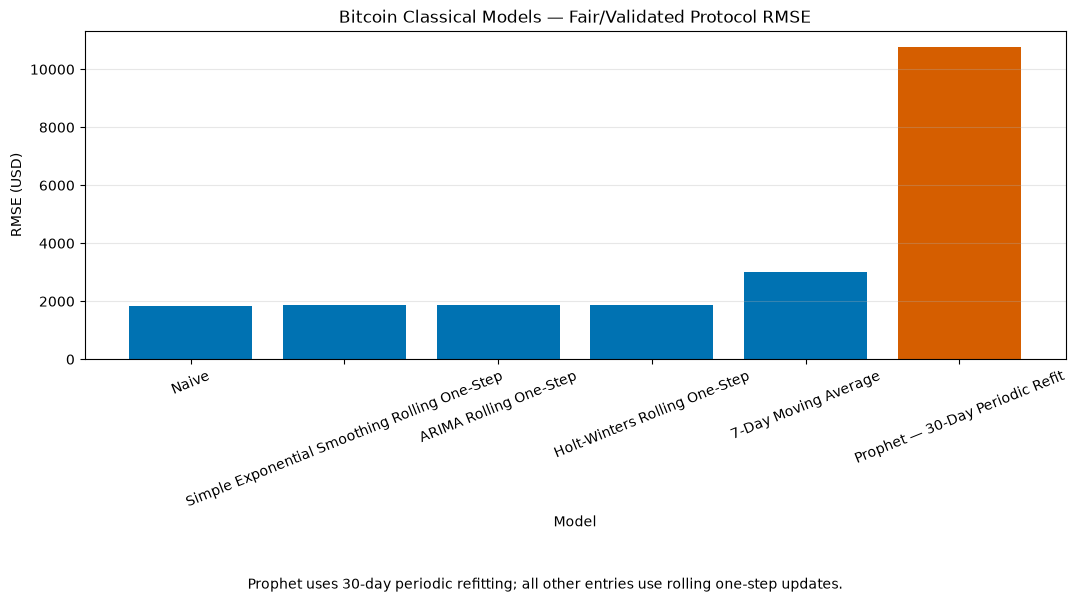

In [13]:
ordered_metrics = metrics_table.sort_values("RMSE")
fig, ax = plt.subplots(figsize=(11, 5.5))
colors = ["#D55E00" if name.startswith("Prophet") else "#0072B2" for name in ordered_metrics.index]
ax.bar(ordered_metrics.index, ordered_metrics["RMSE"], color=colors)
ax.set_title("Bitcoin Classical Models — Fair/Validated Protocol RMSE")
ax.set_xlabel("Model")
ax.set_ylabel("RMSE (USD)")
ax.tick_params(axis="x", rotation=22)
ax.grid(axis="y", alpha=0.3)
fig.text(0.5, -0.08, "Prophet uses 30-day periodic refitting; all other entries use rolling one-step updates.", ha="center")
plt.tight_layout()
plt.show()


## 10. Forecast Alignment Diagnostics


In [14]:
diagnostics = pd.DataFrame({"Actual": y_test, **forecasts})
assert diagnostics.index.equals(test.index)
assert diagnostics.notna().all().all()
assert naive_forecast.equals(target.shift(1).reindex(y_test.index))
assert all(forecast.index.equals(y_test.index) for forecast in forecasts.values())
print("All final forecast vectors align exactly with the 1,061 test dates.")
diagnostics.head(10)


All final forecast vectors align exactly with the 1,061 test dates.


,Actual,Naive,Simple Exponential Smoothing Rolling One-Step,ARIMA Rolling One-Step,Holt-Winters Rolling One-Step,7-Day Moving Average,Prophet — 30-Day Periodic Refit
Timestamp,,,,,,,
2023-08-12 00:00:00+00:00,29415.0,29398.0,29402.736072,29411.966602,29418.077201,29346.000000,29074.863702
2023-08-13 00:00:00+00:00,29284.0,29415.0,29413.634578,29422.050848,29427.341377,29398.285714,29035.169393
2023-08-14 00:00:00+00:00,29408.0,29284.0,29298.577428,29316.287272,29305.240416,29432.857143,28995.475084
2023-08-15 00:00:00+00:00,29172.0,29408.0,29394.207690,29392.138482,29392.951695,29465.285714,28955.780775
2023-08-16 00:00:00+00:00,28701.0,29172.0,29203.802688,29228.198924,29198.951316,29380.714286,28916.086467
2023-08-17 00:00:00+00:00,26642.0,28701.0,28771.068176,28768.867515,28758.039462,29257.285714,28876.392158
2023-08-18 00:00:00+00:00,26051.0,26642.0,26881.932516,26943.091467,26857.103311,28860.000000,28836.697849
2023-08-19 00:00:00+00:00,26097.0,26051.0,26111.901421,26054.881526,26075.026950,28381.857143,28797.003540
2023-08-20 00:00:00+00:00,26192.0,26097.0,26098.150362,26101.346125,26057.319970,27907.857143,28757.309232


Naive is true one-step persistence (`t−1`), and the 7-Day Moving Average uses only the seven observations before each target. Frozen ARIMA, Simple Exponential Smoothing, Holt-Winters, and Prophet vectors are required to match the same test index before comparison.


## 11. Key Findings

- Naive remains the lowest-RMSE classical baseline.
- Simple Exponential Smoothing, rolling ARIMA, and Holt-Winters are highly competitive under the validated rolling one-step protocol.
- Naive versus rolling ARIMA is not statistically significant in the frozen paired DM analysis (`p = 0.308442`).
- The 7-Day Moving Average is materially weaker than Naive and rolling ARIMA.
- Prophet — 30-Day Periodic Refit performs substantially worse and is not presented as daily rolling refit.
- Static long-horizon classical results are development history only and are excluded from final inference.
- No supported weekly seasonality justified retaining a SARIMA comparator.
